In [2]:
import numpy as np
import pandas as pd

from sklearn.model_selection import train_test_split

import matplotlib.pyplot as plt
import seaborn as sns

In [3]:
df = pd.read_csv('train.csv',usecols=['Age','Fare','Survived'])

In [4]:
df.head()

,Survived,Age,Fare
0,0,22.0,7.2500
1,1,38.0,71.2833
2,1,26.0,7.9250
3,1,35.0,53.1000
4,0,35.0,8.0500


In [5]:
df.isnull().mean() * 100

Survived     0.00000
Age         19.86532
Fare         0.00000
dtype: float64

In [6]:
X = df.drop(columns=['Survived'])
y = df['Survived']

In [7]:
X_train,X_test,y_train,y_test = train_test_split(X,y,test_size=0.2,random_state=2)

In [8]:
X_train['Age_imputed'] = X_train['Age']
X_test['Age_imputed'] = X_test['Age']

In [9]:
X_test.tail()

,Age,Fare,Age_imputed
89,24.0,8.0500,24.0
80,22.0,9.0000,22.0
846,NaN,69.5500,NaN
870,26.0,7.8958,26.0
251,29.0,10.4625,29.0


In [10]:
X_train['Age_imputed'][X_train['Age_imputed'].isnull()] = X_train['Age'].dropna().sample(X_train['Age'].isnull().sum()).values
X_test['Age_imputed'][X_test['Age_imputed'].isnull()] = X_train['Age'].dropna().sample(X_test['Age'].isnull().sum()).values

/var/folders/dq/tf6_mpwj1ws9yh7kwt2c5c9r0000gn/T/ipykernel_57020/3090101260.py:1: FutureWarning: ChainedAssignmentError: behaviour will change in pandas 3.0!
You are setting values through chained assignment. Currently this works in certain cases, but when using Copy-on-Write (which will become the default behaviour in pandas 3.0) this will never work to update the original DataFrame or Series, because the intermediate object on which we are setting values will behave as a copy.
A typical example is when you are setting values in a column of a DataFrame, like:

df["col"][row_indexer] = value

Use `df.loc[row_indexer, "col"] = values` instead, to perform the assignment in a single step and ensure this keeps updating the original `df`.

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy

  X_train['Age_imputed'][X_train['Age_imputed'].isnull()] = X_train['Age'].dropna().sample(X_train['Age'].isnull().

```X_train['Age_imputed'][X_train['Age_imputed'].isnull()]``` - Choosing the points where the values are missing
```X_train['Age'].dropna().sample(X_train['Age'].isnull().sum()).values```
  - ```X_train['Age'].dropna()``` - Drops NA columns
  - ```.sample(n)``` - Picks `n` random values
  - ```X_train['Age'].isnull().sum()``` - Count of null values

In [11]:
X_train['Age'].dropna().sample(X_train['Age'].isnull().sum()).values

array([39. , 25. , 36. , 22. , 36. , 28. , 35. , 22. , 47. , 18. ,  5. ,
       48. , 36. , 26. , 18. , 70.5,  2. , 32. , 21. , 29. ,  4. , 23. ,
        4. , 21. , 44. , 19. , 37. , 24. , 25. , 16. , 27. , 23. , 46. ,
       35. , 18. , 27. , 19. , 21. , 17. , 22. , 11. , 17. , 35. , 21. ,
       21. , 24. ,  8. , 14. , 15. , 28. , 16. , 21. , 14. , 54. , 26. ,
       38. , 31. , 27. , 26. , 11. , 48. , 33. , 17. ,  7. , 45.5, 25. ,
       30. , 16. , 26. , 22. ,  4. , 47. , 16. , 27. , 28. , 28. , 12. ,
       36. , 47. , 28.5, 18. , 26. , 28. , 65. , 23. , 60. , 44. , 19. ,
       31. , 18. , 24. ,  2. , 13. , 18. , 31. , 23. , 24. , 18. , 14. ,
       30. , 29. , 23. , 40. , 22. , 34. , 50. , 32. , 19. ,  7. , 47. ,
       40. , 36. , 25. , 28. , 27. , 51. , 58. , 34. , 20. , 57. ,  3. ,
       25. , 21. , 28. , 27. , 24. , 11. ,  4. , 22. , 18. , 22. , 21. ,
       45. , 36. , 40. ,  3. , 19. , 17. , 39. ,  4. , 20. , 19. , 35. ,
       36. , 20. , 10. , 54. , 41. ])

In [12]:
X_train

,Age,Fare,Age_imputed
30,40.0,27.7208,40.0
10,4.0,16.7000,4.0
873,47.0,9.0000,47.0
182,9.0,31.3875,9.0
876,20.0,9.8458,20.0
...,...,...,...
534,30.0,8.6625,30.0
584,NaN,8.7125,24.0
493,71.0,49.5042,71.0
527,NaN,221.7792,33.0


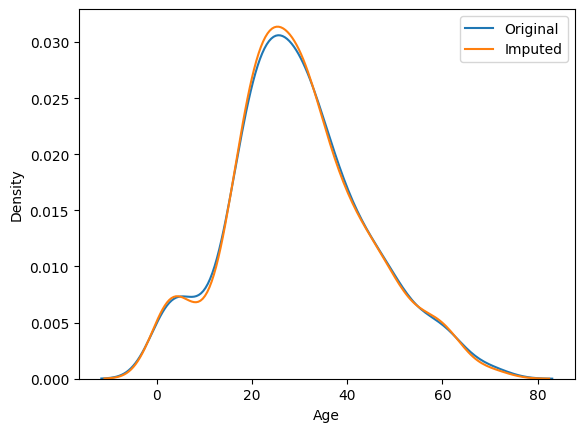

In [13]:
sns.kdeplot(X_train, x='Age',label='Original')
sns.kdeplot(X_train, x='Age_imputed',label='Imputed')

plt.legend()
plt.show()

Distribution remains the same

In [14]:
print('Original variable variance: ', X_train['Age'].var())
print('Variance after random imputation: ', X_train['Age_imputed'].var())

Original variable variance:  204.34951339046142
Variance after random imputation:  200.80448175461052


Variance remains the same

In [15]:
X_train[['Fare', 'Age', 'Age_imputed']].cov()

,Fare,Age,Age_imputed
Fare,2368.246832,71.512440,62.205817
Age,71.512440,204.349513,204.349513
Age_imputed,62.205817,204.349513,200.804482


Some disturbance in covariance

<Axes: >

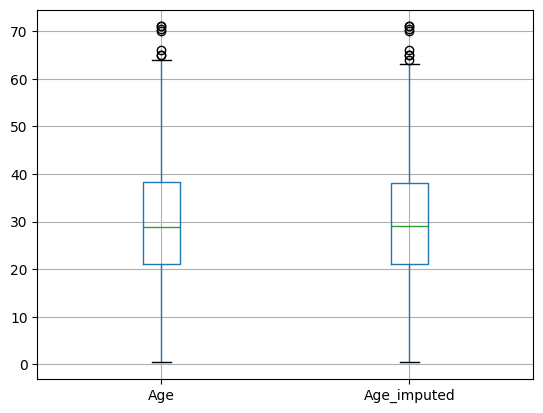

In [16]:
X_train[['Age', 'Age_imputed']].boxplot()

Not much impacts on outliers

In [18]:
data = pd.read_csv('house-train.csv',usecols=['GarageQual','FireplaceQu', 'SalePrice'])

In [19]:
data.head()

,FireplaceQu,GarageQual,SalePrice
0,NaN,TA,208500
1,TA,TA,181500
2,TA,TA,223500
3,Gd,TA,140000
4,TA,TA,250000


In [20]:
data.isnull().mean() * 100

FireplaceQu    47.260274
GarageQual      5.547945
SalePrice       0.000000
dtype: float64

In [21]:
X = data
y = data['SalePrice']

In [22]:
X_train,X_test,y_train,y_test = train_test_split(X,y,test_size=0.2,random_state=2)

In [23]:
X_train['GarageQual_imputed'] = X_train['GarageQual']
X_test['GarageQual_imputed'] = X_test['GarageQual']

X_train['FireplaceQu_imputed'] = X_train['FireplaceQu']
X_test['FireplaceQu_imputed'] = X_test['FireplaceQu']

In [24]:
X_train.sample(5)

,FireplaceQu,GarageQual,SalePrice,GarageQual_imputed,FireplaceQu_imputed
561,TA,TA,170000,TA,TA
1068,Gd,TA,151400,TA,Gd
253,NaN,TA,158000,TA,NaN
940,NaN,TA,150900,TA,NaN
901,NaN,TA,153000,TA,NaN


In [25]:
X_train['GarageQual_imputed'][X_train['GarageQual_imputed'].isnull()] = X_train['GarageQual'].dropna().sample(X_train['GarageQual'].isnull().sum()).values
X_test['GarageQual_imputed'][X_test['GarageQual_imputed'].isnull()] = X_train['GarageQual'].dropna().sample(X_test['GarageQual'].isnull().sum()).values

X_train['FireplaceQu_imputed'][X_train['FireplaceQu_imputed'].isnull()] = X_train['FireplaceQu'].dropna().sample(X_train['FireplaceQu'].isnull().sum()).values
X_test['FireplaceQu_imputed'][X_test['FireplaceQu_imputed'].isnull()] = X_train['FireplaceQu'].dropna().sample(X_test['FireplaceQu'].isnull().sum()).values

/var/folders/dq/tf6_mpwj1ws9yh7kwt2c5c9r0000gn/T/ipykernel_57020/856878696.py:1: FutureWarning: ChainedAssignmentError: behaviour will change in pandas 3.0!
You are setting values through chained assignment. Currently this works in certain cases, but when using Copy-on-Write (which will become the default behaviour in pandas 3.0) this will never work to update the original DataFrame or Series, because the intermediate object on which we are setting values will behave as a copy.
A typical example is when you are setting values in a column of a DataFrame, like:

df["col"][row_indexer] = value

Use `df.loc[row_indexer, "col"] = values` instead, to perform the assignment in a single step and ensure this keeps updating the original `df`.

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy

  X_train['GarageQual_imputed'][X_train['GarageQual_imputed'].isnull()] = X_train['GarageQual'].dropna().sample(X_tr

### Original vs Imputed -- Category frequency

In [26]:
temp = pd.concat(
        [
            X_train['GarageQual'].value_counts() / len(X_train['GarageQual'].dropna()),
            X_train['GarageQual_imputed'].value_counts() / len(X_train)
        ],
        axis=1)

temp.columns = ['original', 'imputed']

In [27]:
temp

,original,imputed
TA,0.951043,0.951199
Fa,0.037171,0.036815
Gd,0.009973,0.010274
Po,0.000907,0.000856
Ex,0.000907,0.000856


In [31]:
temp = pd.concat(
        [
            X_train['FireplaceQu'].value_counts() / len(X_train['FireplaceQu'].dropna()),
            X_train['FireplaceQu_imputed'].value_counts() / len(df)
        ],
        axis=1)

temp.columns = ['original', 'imputed']

temp

,original,imputed
Gd,0.494272,0.650954
TA,0.412439,0.539843
Fa,0.040917,0.052750
Po,0.027823,0.037037
Ex,0.024550,0.030303


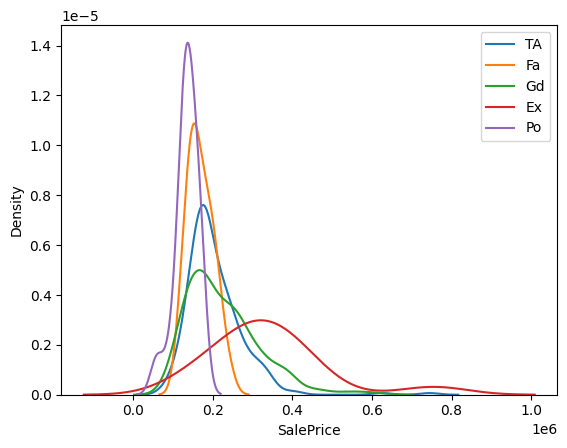

In [30]:
for category in X_train['FireplaceQu'].dropna().unique():
    sns.kdeplot(X_train[X_train['FireplaceQu'] == category]['SalePrice'],label=category)
plt.legend()
plt.show()

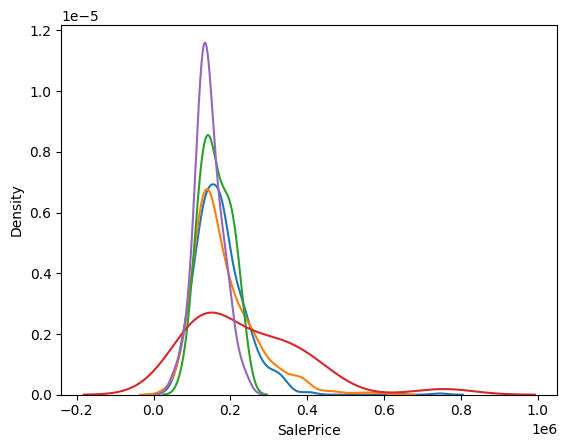

In [32]:
for category in X_train['FireplaceQu_imputed'].dropna().unique():
    sns.kdeplot(X_train[X_train['FireplaceQu_imputed'] == category]['SalePrice'],label=category)
plt.show()